# Notebook 4 — Avaliação de Generalização: Cenários A, B e C

## Protocolo de treino e teste

### Visão geral

Este notebook avalia a capacidade de generalização dos modelos em três cenários progressivamente mais exigentes, cada um executado nos cinco níveis de canais (R5–R0) e com três modelos (RF, XGBoost, LR).

| Cenário | Treino | Teste | Pergunta |
|---------|--------|-------|----------|
| **A — LOSO** | N−1 pacientes do mesmo dataset | paciente deixado de fora | generaliza entre pacientes da mesma base? |
| **B — 1→1** | um dataset inteiro | outro dataset inteiro | transfere entre duas bases? |
| **C — N→1** | vários datasets combinados | uma base não vista | combinar bases ajuda na transferência? |

### Partição e fonte dos dados

As features de treino e teste são geradas no Notebook 3 com **separação cronológica** por paciente — gravações mais antigas compõem o treino, mais recentes o teste. Não há embaralhamento temporal.

**Treino:** janelas de 30 s com passo de 30 s, balanceadas 1:1 (interictal:pré-ictal) por amostragem estratificada no tempo. Usa todas as gravações do paciente, incluindo gravações inteiramente sem crise (CHB-MIT e SeizeIT2) e intervalos intra-arquivo distantes das crises (Siena e Mendeley).

**Teste:** janelas de 30 s com passo de 15 s, em **distribuição natural** — sem balanceamento. O número de janelas interictais é muito maior que o de pré-ictais, refletindo a proporção real do sinal. Todas as gravações do paciente entram no teste.

### Normalização e limiar

O `StandardScaler` é ajustado exclusivamente no conjunto de treino de cada fold e aplicado ao teste sem vazamento. O limiar de decisão é estimado pelo **índice de Youden** no treino (maximiza sensibilidade + especificidade − 1), sem uso do teste para escolha do limiar.

### Critério de alarme

O alarme dispara quando **N_CONSEC = 5 janelas consecutivas** são classificadas como pré-ictal (~60–75 s contínuos). Cada evento pré-ictal é contado no máximo uma vez, independente de quantas vezes o alarme dispare durante o mesmo período.

### Métricas

**Por janela** (avaliam a qualidade da probabilidade — independentes do desbalanceamento do teste via AUC):

| Métrica | Descrição |
|---|---|
| AUC-ROC | área sob a curva ROC; independente do limiar e do desbalanceamento |
| Acurácia | proporção de janelas classificadas corretamente |
| Sensibilidade | proporção de janelas pré-ictais corretamente identificadas |
| Especificidade | proporção de janelas interictais corretamente identificadas |
| F1 | média harmônica de precisão e sensibilidade |
| Precisão | fração das janelas classificadas como pré-ictal que são realmente pré-ictais |

> **Nota sobre F1 e precisão:** o teste usa distribuição natural, com muito mais interictal do que pré-ictal. Isso gera falsos positivos absolutos elevados mesmo com taxa pequena, reduzindo precisão e F1. Isso é metodologicamente correto — o teste deve refletir a realidade clínica. O AUC e as métricas por evento são as mais indicadas para comparação.

**Por evento clínico** (avaliam o comportamento do sistema de alarme):

| Métrica | Descrição |
|---|---|
| Sensibilidade por evento | proporção de crises para as quais o alarme disparou (∈ [0, 1]) |
| FAR/h por janela | falsos positivos por hora (nível de janela) |
| FAR/h por evento | alarmes falsos por hora (nível de evento clínico) |

### Níveis de canais

| Nível | Canais | Qtd | Datasets |
|---|---|---|---|
| R5 | fp1, fp2, f7, f3, fz, f4, f8, t3, t4, t5, t6, c3, c4, p3, p4 | 15 | CHB-MIT, Siena, Mendeley |
| R3 | f7, f3, fz, f4, f8, t3, t4, t5, t6, c3, c4 | 11 | CHB-MIT, Siena, Mendeley |
| R2 | f7, f3, fz, f4, f8, t3, t4, t5, t6 | 9 | CHB-MIT, Siena, Mendeley |
| R1 | t3, t4, t5, t6 | 4 | CHB-MIT, Siena, Mendeley |
| R0 | t3, t4 | 2 | CHB-MIT, Siena, Mendeley, **SeizeIT2** |

O SeizeIT2 possui apenas eletrodos *behind-the-ear* (região temporal), por isso entra somente no nível R0.

## 1. Dependências e configuração

In [1]:
import os
os.environ['LOKY_MAX_CPU_COUNT'] = '4'

%pip install -q numpy pandas matplotlib seaborn scikit-learn xgboost tqdm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os, glob, time, json, gc, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, confusion_matrix, f1_score,
                             precision_score, accuracy_score, roc_curve)
import xgboost as xgb
from tqdm.auto import tqdm
import IPython.display as ipd

import warnings; warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted')

ROOT_DIR = 'data'
FEAT_DIR = os.path.join(ROOT_DIR, 'features')
RESULTS_DIR = os.path.join(ROOT_DIR, 'results'); FIG_DIR = os.path.join(RESULTS_DIR, 'figures')
os.makedirs(RESULTS_DIR, exist_ok=True); os.makedirs(FIG_DIR, exist_ok=True)

N_CONSEC = 5; STEP_TEST_SEC = 15; WIN_SEC = 30; N_FEAT_CH = 19

FEAT_NAMES_BASE = ['std','var','rms','line_len','mobility','skewness','kurtosis',
                   'delta','theta','alpha','beta','gamma','sp_entropy','beta_rel',
                   'dwt_d1','dwt_d2','dwt_d3','dwt_d4','complexity']
BAND_FEATS = {'delta':'Delta','theta':'Theta','alpha':'Alpha','beta':'Beta','gamma':'Gamma'}

PATIENTS = {
    'CHBMIT'  : ['chb01','chb03','chb04','chb05','chb06','chb07','chb08','chb10','chb11','chb12','chb13','chb14'],
    'Siena'   : ['PN01','PN03','PN05','PN06','PN07','PN09','PN10','PN11','PN12','PN13','PN14','PN16'],
    'Mendeley': ['p10','p11','p12','p13','p14','p15'],
    'SeizeIT2': ['sub-001','sub-002','sub-003','sub-004','sub-005','sub-006','sub-007','sub-008','sub-009','sub-010','sub-011','sub-012'],
}
LEVELS = ['R5', 'R3', 'R2', 'R1', 'R0']
LEVEL_DS = {
    'R5': ['CHBMIT','Siena','Mendeley'], 'R3': ['CHBMIT','Siena','Mendeley'],
    'R2': ['CHBMIT','Siena','Mendeley'], 'R1': ['CHBMIT','Siena','Mendeley'],
    'R0': ['CHBMIT','Siena','Mendeley','SeizeIT2'],
}
CHANNEL_SETS = {
    'R5': ['fp1','fp2','f7','f3','fz','f4','f8','t3','t4','t5','t6','c3','c4','p3','p4'],
    'R3': ['f7','f3','fz','f4','f8','t3','t4','t5','t6','c3','c4'],
    'R2': ['f7','f3','fz','f4','f8','t3','t4','t5','t6'],
    'R1': ['t3','t4','t5','t6'], 'R0': ['t3','t4'],
}
CH_REGION = {}
for c in ['fp1','fp2','f7','f3','fz','f4','f8']: CH_REGION[c] = 'Frontal'
for c in ['t3','t4','t5','t6']: CH_REGION[c] = 'Temporal'
for c in ['c3','c4','cz']: CH_REGION[c] = 'Central'
for c in ['p3','p4','pz']: CH_REGION[c] = 'Parietal'
for c in ['o1','o2']: CH_REGION[c] = 'Occipital'

MODELS = ['RF', 'XGB', 'LR']
DS_COLORS = {'CHBMIT':'#4C72B0','Siena':'#DD8452','Mendeley':'#55A868','SeizeIT2':'#C44E52'}

print('Configuração carregada.')
for lv in LEVELS:
    print(f'  {lv}: {len(CHANNEL_SETS[lv]):2d} canais x {N_FEAT_CH} = {len(CHANNEL_SETS[lv])*N_FEAT_CH:4d} features | {LEVEL_DS[lv]}')

Configuração carregada.
  R5: 15 canais x 19 =  285 features | ['CHBMIT', 'Siena', 'Mendeley']
  R3: 11 canais x 19 =  209 features | ['CHBMIT', 'Siena', 'Mendeley']
  R2:  9 canais x 19 =  171 features | ['CHBMIT', 'Siena', 'Mendeley']
  R1:  4 canais x 19 =   76 features | ['CHBMIT', 'Siena', 'Mendeley']
  R0:  2 canais x 19 =   38 features | ['CHBMIT', 'Siena', 'Mendeley', 'SeizeIT2']


c:\Users\danil\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Funções compartilhadas

`fit_eval` padroniza o procedimento: normalização ajustada no treino, treino do modelo, limiar de Youden estimado no treino (sem uso do teste) e avaliação no teste.


In [3]:
def load_feat(dataset, patient, level, mode):
    fp = os.path.join(FEAT_DIR, level, mode, f'{dataset}__{patient}.npz')
    if not os.path.exists(fp):
        return None, None
    z = np.load(fp, allow_pickle=True)
    return z['X'].copy(), z['y'].copy()

def youden_thr(y_tr, p_tr):
    fpr, tpr, thr = roc_curve(y_tr, p_tr)
    return float(thr[np.argmax(tpr - fpr)])

def get_model(name):
    if name == 'RF':
        return RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=5,
            class_weight='balanced', n_jobs=4, random_state=42)
    if name == 'XGB':
        return xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
            n_jobs=4, random_state=42, eval_metric='logloss', verbosity=0)
    if name == 'LR':
        return LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced',
            solver='lbfgs', n_jobs=4, random_state=42)
    raise ValueError(name)

def compute_metrics(y_true, y_prob, thr, dur_h, n_consec=N_CONSEC):
    if len(np.unique(y_true)) < 2:
        return {}
    y_pred = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    far_w = fp / dur_h if dur_h > 0 else 0.0

    # Contar eventos pré-ictais (blocos contíguos de y_true==1)
    n_ev = 0; in_ev = False
    for v in y_true:
        if v == 1 and not in_ev:
            n_ev += 1; in_ev = True
        if v == 0:
            in_ev = False

    # Contagem de alarmes: no máximo 1 detecção por evento pré-ictal.
    # Após disparar um alarme, bloqueia novas contagens até que o período
    # pré-ictal termine (y_true volta a 0). Garante sens_event em [0, 1].
    consec = 0; alarm = False
    n_det = 0; n_fa = 0
    in_preictal = False; event_counted = False

    for yt, yp in zip(y_true, y_pred):
        if yt == 1 and not in_preictal:
            in_preictal = True; event_counted = False
        if yt == 0:
            in_preictal = False; event_counted = False

        consec = (consec + 1) if yp == 1 else 0
        if consec >= n_consec and not alarm:
            alarm = True
            if not event_counted:
                if yt == 1:
                    n_det += 1; event_counted = True
                else:
                    n_fa += 1
        if yp == 0:
            alarm = False

    return dict(auc_roc=round(float(roc_auc_score(y_true, y_prob)), 4),
        accuracy=round(float(accuracy_score(y_true, y_pred)), 4),
        sensitivity=round(sens, 4), specificity=round(spec, 4),
        f1=round(float(f1_score(y_true, y_pred, zero_division=0)), 4),
        precision=round(float(precision_score(y_true, y_pred, zero_division=0)), 4),
        far_window_h=round(far_w, 4), threshold=round(thr, 4),
        sens_event=round(n_det / n_ev if n_ev > 0 else 0.0, 4),
        far_event_h=round(n_fa / dur_h if dur_h > 0 else 0.0, 4),
        n_events=int(n_ev), n_detected=int(n_det), n_false_alarms=int(n_fa),
        n_test_inter=int((y_true == 0).sum()), n_test_pre=int((y_true == 1).sum()))
def get_feat_names_for_level(level):
    return [f'{f}_{ch}' for ch in CHANNEL_SETS[level] for f in FEAT_NAMES_BASE]

def load_done(csv_path, keys):
    if not os.path.exists(csv_path):
        return set()
    df = pd.read_csv(csv_path); cols = [c for c in keys if c in df.columns]
    return set(zip(*[df[c] for c in cols]))

def save_row(row, csv_path):
    pd.DataFrame([row]).to_csv(csv_path, mode='a', header=not os.path.exists(csv_path), index=False)

def load_concat(level, datasets, mode):
    Xs, ys = [], []
    for ds in datasets:
        for p in PATIENTS[ds]:
            X, y = load_feat(ds, p, level, mode)
            if X is None or len(X) == 0:
                continue
            Xs.append(X); ys.append(y)
    if not Xs:
        return None, None
    return np.concatenate(Xs), np.concatenate(ys)

def fit_eval(X_tr, y_tr, X_te, y_te, model_name):
    '''Normaliza, treina, estima limiar de Youden no treino e avalia no teste.'''
    sc = StandardScaler(); X_tr_sc = sc.fit_transform(X_tr); X_te_sc = sc.transform(X_te)
    t0 = time.time(); clf = get_model(model_name); clf.fit(X_tr_sc, y_tr); t_tr = time.time() - t0
    thr = youden_thr(y_tr, clf.predict_proba(X_tr_sc)[:, 1])
    dur_h = len(y_te) * STEP_TEST_SEC / 3600
    proba = clf.predict_proba(X_te_sc)[:, 1]
    mets = compute_metrics(y_te, proba, thr, dur_h)
    fpr, tpr, _ = roc_curve(y_te, proba)
    del X_tr_sc, X_te_sc, clf; gc.collect()
    return mets, t_tr, fpr, tpr

print('Funções compartilhadas definidas.')

Funções compartilhadas definidas.


## 3. Cenário A — generalização entre pacientes (LOSO)

Treino em todos os pacientes do dataset menos um, teste no paciente excluído (*leave-one-subject-out*). Mede a generalização entre indivíduos dentro da mesma base.


In [4]:
CSV_A = os.path.join(RESULTS_DIR, 'cenario_A_loso.csv')

def run_fold_A(level, dataset, test_pat, model_name):
    train_pats = [p for p in PATIENTS[dataset] if p != test_pat]
    Xs, ys = [], []
    for p in train_pats:
        X, y = load_feat(dataset, p, level, 'train')
        if X is None or len(X) == 0:
            continue
        Xs.append(X); ys.append(y)
    if not Xs:
        return None
    X_tr = np.concatenate(Xs); y_tr = np.concatenate(ys); del Xs, ys; gc.collect()
    X_te, y_te = load_feat(dataset, test_pat, level, 'test')
    if X_te is None or len(X_te) == 0 or y_te.sum() == 0 or y_tr.sum() == 0:
        return None
    mets, t_tr, fpr, tpr = fit_eval(X_tr, y_tr, X_te, y_te, model_name)
    del X_tr, X_te; gc.collect()
    if not mets:
        return None
    return dict(scenario='A_LOSO', level=level, dataset=dataset, test_patient=test_pat,
                model=model_name, t_train_s=round(t_tr, 2),
                roc_fpr=json.dumps([round(x, 4) for x in fpr.tolist()]),
                roc_tpr=json.dumps([round(x, 4) for x in tpr.tolist()]), **mets)

done_A = load_done(CSV_A, ['level', 'dataset', 'test_patient', 'model'])
todo_A = [(lv, ds, pat, mdl) for lv in LEVELS for ds in LEVEL_DS[lv]
          for pat in PATIENTS[ds] for mdl in MODELS if (lv, ds, pat, mdl) not in done_A]
print(f'Cenário A — execuções pendentes: {len(todo_A)}')
for lv, ds, pat, mdl in tqdm(todo_A, desc='Cenário A', ncols=110):
    row = run_fold_A(lv, ds, pat, mdl)
    if row is not None:
        save_row(row, CSV_A)
if os.path.exists(CSV_A):
    df_A = pd.read_csv(CSV_A)
    print('Cenário A concluído.')
    MAIN_METRICS = ['auc_roc', 'sensitivity', 'specificity', 'sens_event', 'far_event_h']
    ALL_METRICS  = ['auc_roc', 'accuracy', 'sensitivity', 'specificity', 'f1', 'precision', 'far_window_h', 'sens_event', 'far_event_h']
    ipd.display(df_A.groupby(['level', 'dataset', 'model'])[MAIN_METRICS].mean().round(3))
    df_A.groupby(['level', 'dataset', 'model'])[ALL_METRICS].mean().round(3).to_csv(
        os.path.join(RESULTS_DIR, 'cenario_A_completo.csv'))

Cenário A — execuções pendentes: 0


Cenário A: 0it [00:00, ?it/s]


Cenário A concluído.


auc_roc  sensitivity  specificity  sens_event  \
level dataset  model                                                  
R0    CHBMIT   LR       0.474        0.528        0.474       0.917   
               RF       0.556        0.406        0.668       0.917   
               XGB      0.538        0.447        0.603       1.000   
      Mendeley LR       0.521        0.694        0.307       0.833   
               RF       0.490        0.647        0.397       0.833   
               XGB      0.495        0.515        0.494       1.000   
      SeizeIT2 LR       0.520        0.547        0.465       0.833   
               RF       0.524        0.416        0.610       0.750   
               XGB      0.509        0.383        0.610       0.667   
      Siena    LR       0.532        0.494        0.510       0.833   
               RF       0.468        0.363        0.584       0.750   
               XGB      0.478        0.278        0.690       0.583   
R1    CHBMIT   LR       0.492        0.514        0.483       0.833   
               RF       0.540        0.381        0.695       0.917   
               XGB      0.529        0.308        0.741       0.750   
      Mendeley LR       0.499        0.746        0.229       1.000   
               RF       0.446        0.594        0.345       0.833   
               XGB      0.482        0.387        0.630       1.000   
      Siena    LR       0.474        0.441        0.542       0.833   
               RF       0.451        0.357        0.611       0.750   
               XGB      0.481        0.165        0.811       0.500   
R2    CHBMIT   LR       0.446        0.444        0.516       0.833   
               RF       0.511        0.358        0.654       0.833   
               XGB      0.526        0.278        0.733       0.583   
      Mendeley LR       0.505        0.411        0.567       0.500   
               RF       0.490        0.572        0.438       0.667   
               XGB      0.471        0.234        0.784       0.500   
      Siena    LR       0.416        0.356        0.498       0.667   
               RF       0.434        0.350        0.598       0.750   
               XGB      0.432        0.100        0.880       0.333   
R3    CHBMIT   LR       0.451        0.437        0.499       0.833   
               RF       0.514        0.375        0.653       0.917   
               XGB      0.530        0.218        0.802       0.667   
      Mendeley LR       0.590        0.488        0.573       0.667   
               RF       0.442        0.552        0.434       1.000   
               XGB      0.444        0.321        0.687       0.500   
      Siena    LR       0.454        0.403        0.539       0.750   
               RF       0.445        0.324        0.613       0.750   
               XGB      0.427        0.087        0.883       0.250   
R5    CHBMIT   LR       0.494        0.479        0.517       0.833   
               RF       0.540        0.330        0.673       0.833   
               XGB      0.552        0.176        0.860       0.583   
      Mendeley LR       0.559        0.534        0.476       0.833   
               RF       0.504        0.571        0.466       0.833   
               XGB      0.489        0.191        0.833       0.500   
      Siena    LR       0.427        0.359        0.558       0.667   
               RF       0.419        0.314        0.616       0.750   
               XGB      0.407        0.084        0.885       0.083   

                      far_event_h  
level dataset  model               
R0    CHBMIT   LR           5.475  
               RF           3.771  
               XGB          5.154  
      Mendeley LR           2.597  
               RF           1.964  
               XGB          2.195  
      SeizeIT2 LR           4.508  
               RF           5.202  
               XGB          5.298  
      Siena    LR           5.245  
               RF           5.214  
   

## 4. Cenário B — transferência entre dois datasets

Treino em um dataset, teste em outro, em todas as direções (A→B e B→A são distintas). Combinam-se apenas datasets que compartilham o nível de canais. No R0, inclui as combinações com SeizeIT2.


In [5]:
CSV_B = os.path.join(RESULTS_DIR, 'cenario_B_cross_1to1.csv')

def pairs_1to1(level):
    avail = LEVEL_DS[level]
    return [(a, b) for a in avail for b in avail if a != b]

def run_B(level, train_ds, test_ds, model_name):
    X_tr, y_tr = load_concat(level, [train_ds], 'train')
    if X_tr is None or y_tr.sum() == 0:
        return None
    X_te, y_te = load_concat(level, [test_ds], 'test')
    if X_te is None or y_te.sum() == 0:
        return None
    mets, t_tr, fpr, tpr = fit_eval(X_tr, y_tr, X_te, y_te, model_name)
    del X_tr, X_te; gc.collect()
    if not mets:
        return None
    return dict(scenario='B_cross_1to1', level=level, train_dataset=train_ds,
                test_dataset=test_ds, model=model_name, t_train_s=round(t_tr, 2),
                roc_fpr=json.dumps([round(x, 4) for x in fpr.tolist()]),
                roc_tpr=json.dumps([round(x, 4) for x in tpr.tolist()]), **mets)

done_B = load_done(CSV_B, ['level', 'train_dataset', 'test_dataset', 'model'])
todo_B = []
for lv in LEVELS:
    for a, b in pairs_1to1(lv):
        for mdl in MODELS:
            if (lv, a, b, mdl) not in done_B:
                todo_B.append((lv, a, b, mdl))
print(f'Cenário B — execuções pendentes: {len(todo_B)}')
for lv, a, b, mdl in tqdm(todo_B, desc='Cenário B', ncols=110):
    row = run_B(lv, a, b, mdl)
    if row is not None:
        save_row(row, CSV_B)
if os.path.exists(CSV_B):
    df_B = pd.read_csv(CSV_B)
    print('Cenário B concluído.')
    MAIN_METRICS = ['auc_roc', 'sensitivity', 'specificity', 'sens_event', 'far_event_h']
    ALL_METRICS  = ['auc_roc', 'accuracy', 'sensitivity', 'specificity', 'f1', 'precision', 'far_window_h', 'sens_event', 'far_event_h']
    ipd.display(df_B.groupby(['level', 'train_dataset', 'test_dataset', 'model'])[MAIN_METRICS].mean().round(3).head(40))
    df_B.groupby(['level', 'train_dataset', 'test_dataset', 'model'])[ALL_METRICS].mean().round(3).to_csv(
        os.path.join(RESULTS_DIR, 'cenario_B_completo.csv'))

Cenário B — execuções pendentes: 0


Cenário B: 0it [00:00, ?it/s]

Cenário B concluído.


auc_roc  sensitivity  specificity  \
level train_dataset test_dataset model                                      
R0    CHBMIT        Mendeley     LR       0.523        0.240        0.778   
                                 RF       0.494        0.455        0.534   
                                 XGB      0.480        0.439        0.515   
                    SeizeIT2     LR       0.636        0.901        0.253   
                                 RF       0.459        0.217        0.645   
                                 XGB      0.432        0.171        0.674   
                    Siena        LR       0.491        0.322        0.648   
                                 RF       0.474        0.478        0.486   
                                 XGB      0.416        0.406        0.476   
      Mendeley      CHBMIT       LR       0.507        0.313        0.759   
                                 RF       0.573        0.514        0.586   
                                 XGB      0.589        0.496        0.628   
                    SeizeIT2     LR       0.546        0.185        0.798   
                                 RF       0.571        0.059        0.906   
                                 XGB      0.512        0.024        0.967   
                    Siena        LR       0.369        0.133        0.719   
                                 RF       0.380        0.065        0.757   
                                 XGB      0.390        0.047        0.840   
      SeizeIT2      CHBMIT       LR       0.465        0.542        0.436   
                                 RF       0.493        0.208        0.744   
                                 XGB      0.579        0.390        0.733   
                    Mendeley     LR       0.521        0.715        0.334   
                                 RF       0.483        0.369        0.603   
                                 XGB      0.446        0.289        0.636   
                    Siena        LR       0.535        0.439        0.624   
                                 RF       0.425        0.189        0.732   
                                 XGB      0.437        0.175        0.744   
      Siena         CHBMIT       LR       0.537        0.718        0.317   
                                 RF       0.526        0.529        0.497   
                                 XGB      0.473        0.326        0.662   
                    Mendeley     LR       0.420        0.101        0.792   
                                 RF       0.447        0.096        0.889   
                                 XGB      0.422        0.045        0.950   
                    SeizeIT2     LR       0.624        0.953        0.092   
                                 RF       0.389        0.116        0.802   
                                 XGB      0.434        0.085        0.833   
R1    CHBMIT        Mendeley     LR       0.474        0.188        0.780   
                                 RF       0.501        0.185        0.808   
                                 XGB      0.521        0.232        0.814   
                    Siena        LR       0.497        0.255        0.705   

                                        sens_event  far_event_h  
level train_dataset test_dataset model                           
R0    CHBMIT        Mendeley     LR          0.833        1.527  
                                 RF          1.000        3.162  
                                 XGB         1.000        3.707  
                    SeizeIT2     LR          0.417        1.951  
                                 RF          0.667        3.288  
                                 XGB         0.417        3.498  
                    Siena        LR          0.833        4.300  
                                 RF          0.917        6.072  
                                 XGB         0.833        6.662  
      Mendeley      CHBMIT       LR          0.750        2.328  
             

## 5. Cenário C — combinação de múltiplos datasets

Treino na união de dois ou mais datasets, teste em uma base não incluída no treino. Avalia se a diversidade de fontes melhora a transferência. Inclui combinações 2→1 e, no R0 (quatro datasets), também 3→1.


In [6]:
CSV_C = os.path.join(RESULTS_DIR, 'cenario_C_cross_Nto1.csv')

def combos_Nto1(level):
    '''Treino com dois ou mais datasets, teste em um deixado de fora.'''
    avail = LEVEL_DS[level]; out = []
    for test_ds in avail:
        others = [d for d in avail if d != test_ds]
        for r in range(2, len(others) + 1):
            for tr in itertools.combinations(others, r):
                out.append((list(tr), test_ds))
    return out

def run_C(level, train_sets, test_ds, model_name):
    X_tr, y_tr = load_concat(level, train_sets, 'train')
    if X_tr is None or y_tr.sum() == 0:
        return None
    X_te, y_te = load_concat(level, [test_ds], 'test')
    if X_te is None or y_te.sum() == 0:
        return None
    mets, t_tr, fpr, tpr = fit_eval(X_tr, y_tr, X_te, y_te, model_name)
    del X_tr, X_te; gc.collect()
    if not mets:
        return None
    return dict(scenario='C_cross_Nto1', level=level, train_sets='+'.join(train_sets),
                test_dataset=test_ds, model=model_name, t_train_s=round(t_tr, 2),
                roc_fpr=json.dumps([round(x, 4) for x in fpr.tolist()]),
                roc_tpr=json.dumps([round(x, 4) for x in tpr.tolist()]), **mets)

done_C = load_done(CSV_C, ['level', 'train_sets', 'test_dataset', 'model'])
todo_C = []
for lv in LEVELS:
    for tr, te in combos_Nto1(lv):
        for mdl in MODELS:
            key = (lv, '+'.join(tr), te, mdl)
            if key not in done_C:
                todo_C.append((lv, tr, te, mdl))
print(f'Cenário C — execuções pendentes: {len(todo_C)}')
for lv, tr, te, mdl in tqdm(todo_C, desc='Cenário C', ncols=110):
    row = run_C(lv, tr, te, mdl)
    if row is not None:
        save_row(row, CSV_C)
if os.path.exists(CSV_C):
    df_C = pd.read_csv(CSV_C)
    print('Cenário C concluído.')
    MAIN_METRICS = ['auc_roc', 'sensitivity', 'specificity', 'sens_event', 'far_event_h']
    ALL_METRICS  = ['auc_roc', 'accuracy', 'sensitivity', 'specificity', 'f1', 'precision', 'far_window_h', 'sens_event', 'far_event_h']
    ipd.display(df_C.groupby(['level', 'train_sets', 'test_dataset', 'model'])[MAIN_METRICS].mean().round(3).head(40))
    df_C.groupby(['level', 'train_sets', 'test_dataset', 'model'])[ALL_METRICS].mean().round(3).to_csv(
        os.path.join(RESULTS_DIR, 'cenario_C_completo.csv'))

Cenário C — execuções pendentes: 0


Cenário C: 0it [00:00, ?it/s]


Cenário C concluído.


auc_roc  sensitivity  \
level train_sets               test_dataset model                         
R0    CHBMIT+Mendeley          SeizeIT2     LR       0.632        0.860   
                                            RF       0.400        0.160   
                                            XGB      0.430        0.120   
                               Siena        LR       0.389        0.232   
                                            RF       0.454        0.398   
                                            XGB      0.420        0.292   
      CHBMIT+Mendeley+SeizeIT2 Siena        LR       0.410        0.296   
                                            RF       0.434        0.264   
                                            XGB      0.422        0.297   
      CHBMIT+SeizeIT2          Mendeley     LR       0.497        0.306   
                                            RF       0.487        0.439   
                                            XGB      0.516        0.430   
                               Siena        LR       0.530        0.526   
                                            RF       0.454        0.287   
                                            XGB      0.439        0.306   
      CHBMIT+Siena             Mendeley     LR       0.503        0.232   
                                            RF       0.493        0.218   
                                            XGB      0.474        0.205   
                               SeizeIT2     LR       0.628        0.983   
                                            RF       0.421        0.145   
                                            XGB      0.419        0.159   
      CHBMIT+Siena+Mendeley    SeizeIT2     LR       0.632        0.937   
                                            RF       0.416        0.124   
                                            XGB      0.400        0.160   
      CHBMIT+Siena+SeizeIT2    Mendeley     LR       0.487        0.221   
                                            RF       0.481        0.226   
                                            XGB      0.492        0.210   
      Mendeley+SeizeIT2        CHBMIT       LR       0.499        0.503   
                                            RF       0.560        0.545   
                                            XGB      0.578        0.512   
                               Siena        LR       0.403        0.339   
                                            RF       0.346        0.175   
                                            XGB      0.381        0.172   
      Siena+Mendeley           CHBMIT       LR       0.598        0.457   
                                            RF       0.561        0.656   
                                            XGB      0.593        0.703   
                               SeizeIT2     LR       0.610        0.807   
                                            RF       0.416        0.115   
                                            XGB      0.413        0.132   
      Siena+Mendeley+SeizeIT2  CHBMIT       LR       0.548        0.770   

                                                   specificity  sens_event  \
level train_sets               test_dataset model                            
R0    CHBMIT+Mendeley          SeizeIT2     LR           0.317       0.333   
                                            RF           0.684       0.417   
                                            XGB          0.775       0.333   
                               Siena        LR           0.600       0.750   
                                            RF           0.546       0.917   
                                            XGB          0.616       0.833   
      CHBMIT+Mendeley+SeizeIT2 Siena        LR           0.568       0.750   
                                            RF           0.660       0.917   
                                            XGB          0.602       0.917   
      CHBMIT+SeizeIT2          Mendeley   

## 6. Comparação entre cenários

Reúne A, B e C para quantificar a perda de desempenho ao sair da mesma base (A) para a transferência entre bases (B) e a eventual recuperação ao combinar bases (C). A segunda figura mostra o efeito da redução de canais sobre o AUC, central para a questão do uso vestível.


AUC e sensibilidade por evento, por cenário e modelo:


,cenario,model,auc_roc,sensitivity,specificity,sens_event,far_event_h,n
0,A_LOSO,LR,0.483,0.477,0.495,0.796,4.420,162
1,A_LOSO,RF,0.488,0.403,0.594,0.815,3.856,162
2,A_LOSO,XGB,0.489,0.248,0.757,0.574,2.372,162
3,B_cross_1to1,LR,0.479,0.335,0.639,0.657,2.790,36
4,B_cross_1to1,RF,0.479,0.265,0.709,0.600,2.384,36
5,B_cross_1to1,XGB,0.467,0.160,0.824,0.451,1.773,36
6,C_cross_Nto1,LR,0.497,0.461,0.526,0.679,3.374,28
7,C_cross_Nto1,RF,0.466,0.352,0.628,0.708,2.971,28
8,C_cross_Nto1,XGB,0.462,0.304,0.661,0.711,3.244,28


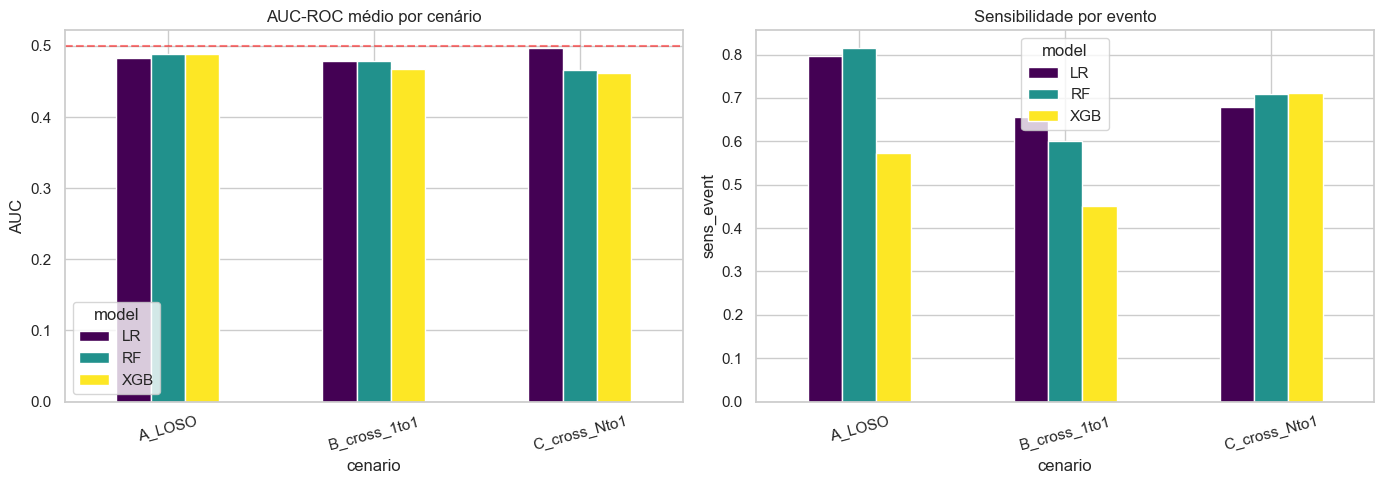

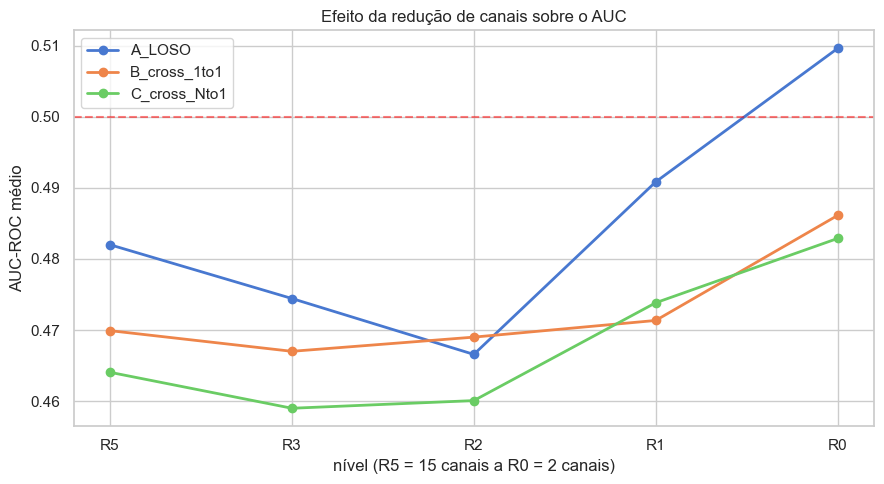

In [7]:
frames = []
for csv, scen in [(CSV_A, 'A_LOSO'), (CSV_B, 'B_cross_1to1'), (CSV_C, 'C_cross_Nto1')]:
    if os.path.exists(csv):
        d = pd.read_csv(csv); d['cenario'] = scen; frames.append(d)
if frames:
    allres = pd.concat(frames, ignore_index=True)
    print('AUC e sensibilidade por evento, por cenário e modelo:')
    comp = allres.groupby(['cenario', 'model']).agg(
        auc_roc=('auc_roc', 'mean'),
        sensitivity=('sensitivity', 'mean'),
        specificity=('specificity', 'mean'),
        sens_event=('sens_event', 'mean'),
        far_event_h=('far_event_h', 'mean'),
        n=('auc_roc', 'size')).round(3).reset_index()
    ipd.display(comp)
    # CSV completo com todas as métricas
    allres.groupby(['cenario', 'model']).agg(
        auc_roc=('auc_roc', 'mean'), accuracy=('accuracy', 'mean'),
        sensitivity=('sensitivity', 'mean'), specificity=('specificity', 'mean'),
        f1=('f1', 'mean'), precision=('precision', 'mean'),
        far_window_h=('far_window_h', 'mean'),
        sens_event=('sens_event', 'mean'), far_event_h=('far_event_h', 'mean'),
        n=('auc_roc', 'size')).round(3).reset_index().to_csv(
        os.path.join(RESULTS_DIR, 'comparacao_cenarios_completo.csv'), index=False)

    order = ['A_LOSO', 'B_cross_1to1', 'C_cross_Nto1']
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    piv = comp.pivot(index='cenario', columns='model', values='auc_roc').reindex(order)
    piv.plot(kind='bar', ax=axes[0], colormap='viridis')
    axes[0].set_title('AUC-ROC médio por cenário')
    axes[0].set_ylabel('AUC'); axes[0].axhline(0.5, color='red', ls='--', alpha=0.5)
    axes[0].tick_params(axis='x', rotation=15)
    piv2 = comp.pivot(index='cenario', columns='model', values='sens_event').reindex(order)
    piv2.plot(kind='bar', ax=axes[1], colormap='viridis')
    axes[1].set_title('Sensibilidade por evento')
    axes[1].set_ylabel('sens_event'); axes[1].tick_params(axis='x', rotation=15)
    plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, 'comparacao_cenarios.png'), dpi=140, bbox_inches='tight')
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 5))
    for scen in order:
        sub = allres[allres['cenario'] == scen]
        if sub.empty:
            continue
        m = sub.groupby('level')['auc_roc'].mean().reindex(LEVELS)
        ax.plot(LEVELS, m.values, marker='o', label=scen, linewidth=2)
    ax.set_title('Efeito da redução de canais sobre o AUC')
    ax.set_xlabel('nível (R5 = 15 canais a R0 = 2 canais)'); ax.set_ylabel('AUC-ROC médio')
    ax.axhline(0.5, color='red', ls='--', alpha=0.5); ax.legend()
    plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, 'impacto_canais.png'), dpi=140, bbox_inches='tight')
    plt.show()
else:
    print('Execute os cenários A, B e C primeiro.')

## 7. Importância das features por região e banda

Treina o modelo de melhor AUC médio e agrega a importância das features por banda de frequência e por região cortical, indicando quais ritmos e regiões mais contribuem para a discriminação do pré-ictal.


Modelo de melhor AUC médio: RF


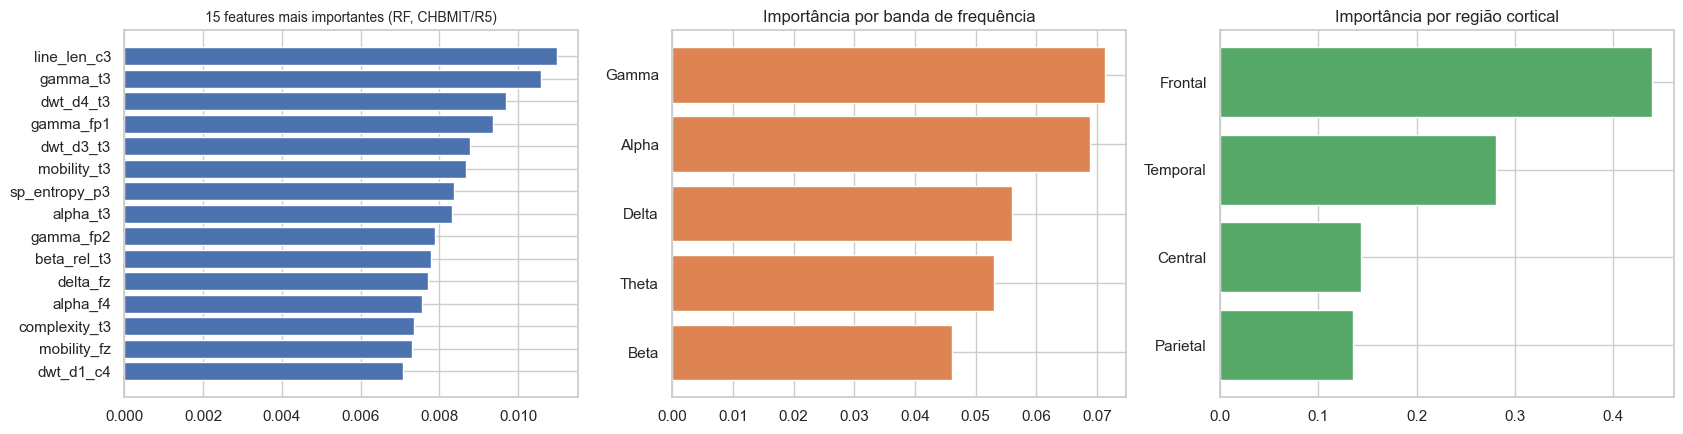

In [8]:
def best_model_overall():
    try:
        if not frames:
            return 'RF'
        return allres.groupby('model')['auc_roc'].mean().idxmax()
    except NameError:
        return 'RF'

def importance_analysis(level='R5', dataset='CHBMIT', model_name=None):
    model_name = model_name or best_model_overall()
    Xs, ys = [], []
    for p in PATIENTS[dataset]:
        X, y = load_feat(dataset, p, level, 'train')
        if X is not None and len(X) > 0:
            Xs.append(X); ys.append(y)
    if not Xs:
        print('Sem dados para a análise.'); return
    X = np.concatenate(Xs); y = np.concatenate(ys)
    sc = StandardScaler(); Xs_ = sc.fit_transform(X)
    clf = get_model(model_name); clf.fit(Xs_, y)
    names = get_feat_names_for_level(level)
    imp = clf.feature_importances_ if model_name in ('RF', 'XGB') else np.abs(clf.coef_[0])
    dfi = pd.DataFrame({'feature': names, 'importance': imp})
    dfi['base'] = dfi['feature'].apply(lambda s: s.rsplit('_', 1)[0])
    dfi['chan'] = dfi['feature'].apply(lambda s: s.rsplit('_', 1)[1])
    dfi['regiao'] = dfi['chan'].map(CH_REGION).fillna('Outro')
    dfi['banda'] = dfi['base'].map(BAND_FEATS).fillna('-')

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
    top = dfi.nlargest(15, 'importance').iloc[::-1]
    axes[0].barh(top['feature'], top['importance'], color='#4C72B0')
    axes[0].set_title(f'15 features mais importantes ({model_name}, {dataset}/{level})', fontsize=10)
    band = dfi[dfi['banda'] != '-'].groupby('banda')['importance'].sum().sort_values()
    axes[1].barh(band.index, band.values, color='#DD8452')
    axes[1].set_title('Importância por banda de frequência')
    reg = dfi.groupby('regiao')['importance'].sum().sort_values()
    axes[2].barh(reg.index, reg.values, color='#55A868')
    axes[2].set_title('Importância por região cortical')
    plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, f'importance_{dataset}_{level}.png'),
                                    dpi=140, bbox_inches='tight')
    plt.show()
    return dfi

print(f'Modelo de melhor AUC médio: {best_model_overall()}')
_ = importance_analysis(level='R5', dataset='CHBMIT')

## 8. Interpretabilidade aprofundada — SHAP e Permutation Importance

A `importance_analysis` da seção anterior usa a importância intrínseca do RF/XGB
(`feature_importances_`), que reflete a redução de impureza no treino e pode
superestimar features de alta cardinalidade. As duas abordagens abaixo são
mais robustas:

**Permutation Importance** embaralha cada feature no conjunto de *teste* e mede
a queda de AUC — features que causam maior queda são mais importantes para a
generalização, não apenas para o ajuste ao treino.

**SHAP** (*SHapley Additive exPlanations*) calcula a contribuição marginal de
cada feature para cada predição individual, com garantia teórica de consistência.
Permite visualizar quais features empurram a predição para pré-ictal ou interictal,
por amostra e em média.

Ambas as análises são executadas no **modelo vencedor** (maior AUC médio nos
cenários A/B/C) no nível R5 do CHB-MIT, por ser o dataset com mais dados e
cobertura completa de canais. Altere `INTERP_LEVEL` e `INTERP_DS` conforme
necessário.


In [9]:
%pip install -q shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Modelo vencedor: RF | nível: R5 | dataset: CHBMIT
Treinando para análise de interpretabilidade...
Treino: (3698, 285) | Teste: (50718, 285)

Calculando Permutation Importance (10 repetições no teste)...


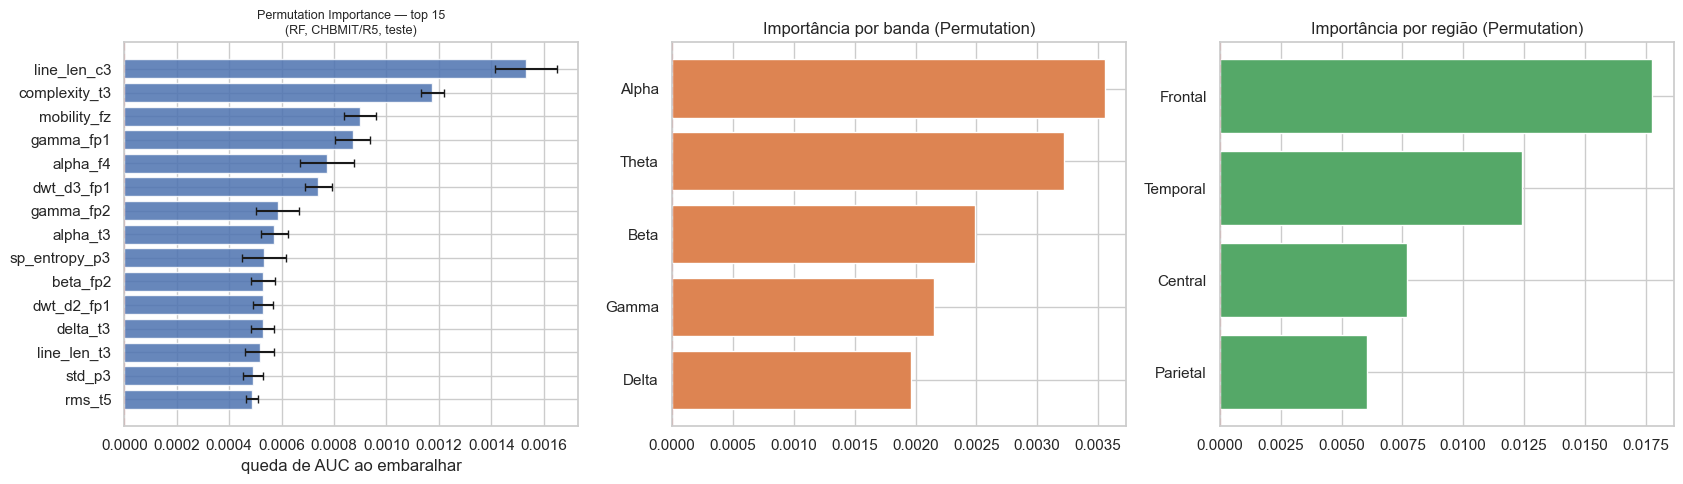

Permutation Importance concluída.
Top 5 features: ['line_len_c3', 'complexity_t3', 'mobility_fz', 'gamma_fp1', 'alpha_f4']


In [10]:
from sklearn.inspection import permutation_importance

# ── Parâmetros da análise de interpretabilidade ──
INTERP_LEVEL   = 'R5'
INTERP_DS      = 'CHBMIT'
INTERP_N_REPEAT = 10    # repetições do embaralhamento (mais = mais estável, mais lento)

def build_interp_data(level, dataset, model_name):
    '''Treina o modelo vencedor em todos os pacientes do dataset (nível escolhido).
    Retorna (clf, sc, X_tr_sc, y_tr, X_te_sc, y_te, feat_names).'''
    Xtr, ytr, Xte, yte = [], [], [], []
    for p in PATIENTS[dataset]:
        X, y = load_feat(dataset, p, level, 'train')
        if X is not None and len(X) > 0: Xtr.append(X); ytr.append(y)
        X, y = load_feat(dataset, p, level, 'test')
        if X is not None and len(X) > 0: Xte.append(X); yte.append(y)
    X_tr = np.concatenate(Xtr); y_tr = np.concatenate(ytr)
    X_te = np.concatenate(Xte); y_te = np.concatenate(yte)
    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_te_sc = sc.transform(X_te)
    clf = get_model(model_name); clf.fit(X_tr_sc, y_tr)
    feat_names = get_feat_names_for_level(level)
    return clf, sc, X_tr_sc, y_tr, X_te_sc, y_te, feat_names

model_venc = best_model_overall()
print(f'Modelo vencedor: {model_venc} | nível: {INTERP_LEVEL} | dataset: {INTERP_DS}')
print('Treinando para análise de interpretabilidade...')

clf_interp, sc_interp, X_tr_sc, y_tr, X_te_sc, y_te, feat_names = \
    build_interp_data(INTERP_LEVEL, INTERP_DS, model_venc)

print(f'Treino: {X_tr_sc.shape} | Teste: {X_te_sc.shape}')

# ── Permutation Importance (no conjunto de TESTE) ──
print(f'\nCalculando Permutation Importance ({INTERP_N_REPEAT} repetições no teste)...')
perm = permutation_importance(
    clf_interp, X_te_sc, y_te,
    scoring='roc_auc', n_repeats=INTERP_N_REPEAT,
    n_jobs=4, random_state=42
)

df_perm = pd.DataFrame({
    'feature'   : feat_names,
    'importance': perm.importances_mean,
    'std'       : perm.importances_std,
}).sort_values('importance', ascending=False).reset_index(drop=True)

df_perm['base']   = df_perm['feature'].apply(lambda s: s.rsplit('_', 1)[0])
df_perm['chan']   = df_perm['feature'].apply(lambda s: s.rsplit('_', 1)[1])
df_perm['regiao'] = df_perm['chan'].map(CH_REGION).fillna('Outro')
df_perm['banda']  = df_perm['base'].map(BAND_FEATS).fillna('-')
df_perm.to_csv(os.path.join(RESULTS_DIR, f'permutation_importance_{INTERP_DS}_{INTERP_LEVEL}.csv'), index=False)

# Gráficos
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

top_perm = df_perm.head(15).iloc[::-1]
axes[0].barh(top_perm['feature'], top_perm['importance'],
             xerr=top_perm['std'], color='#4C72B0', alpha=0.85, capsize=3)
axes[0].axvline(0, color='red', ls='--', alpha=0.5)
axes[0].set_title(f'Permutation Importance — top 15\n({model_venc}, {INTERP_DS}/{INTERP_LEVEL}, teste)', fontsize=9)
axes[0].set_xlabel('queda de AUC ao embaralhar')

band_perm = df_perm[df_perm['banda'] != '-'].groupby('banda')['importance'].sum().sort_values()
axes[1].barh(band_perm.index, band_perm.values, color='#DD8452')
axes[1].set_title('Importância por banda (Permutation)')
axes[1].axvline(0, color='red', ls='--', alpha=0.5)

reg_perm = df_perm.groupby('regiao')['importance'].sum().sort_values()
axes[2].barh(reg_perm.index, reg_perm.values, color='#55A868')
axes[2].set_title('Importância por região (Permutation)')
axes[2].axvline(0, color='red', ls='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f'permutation_importance_{INTERP_DS}_{INTERP_LEVEL}.png'),
            dpi=140, bbox_inches='tight')
plt.show()

print('Permutation Importance concluída.')
print(f'Top 5 features: {df_perm["feature"].head(5).tolist()}')


### SHAP — valores de Shapley por amostra

O SHAP é calculado em uma amostra do conjunto de teste para controlar o tempo
de execução. `TreeExplainer` é nativo para RF e XGB (sem aproximação).
Para LR usa-se `LinearExplainer`.


Calculando SHAP (RF)...
  amostras: 300 (150 interictal + 150 pré-ictal)
Gerando beeswarm plot...


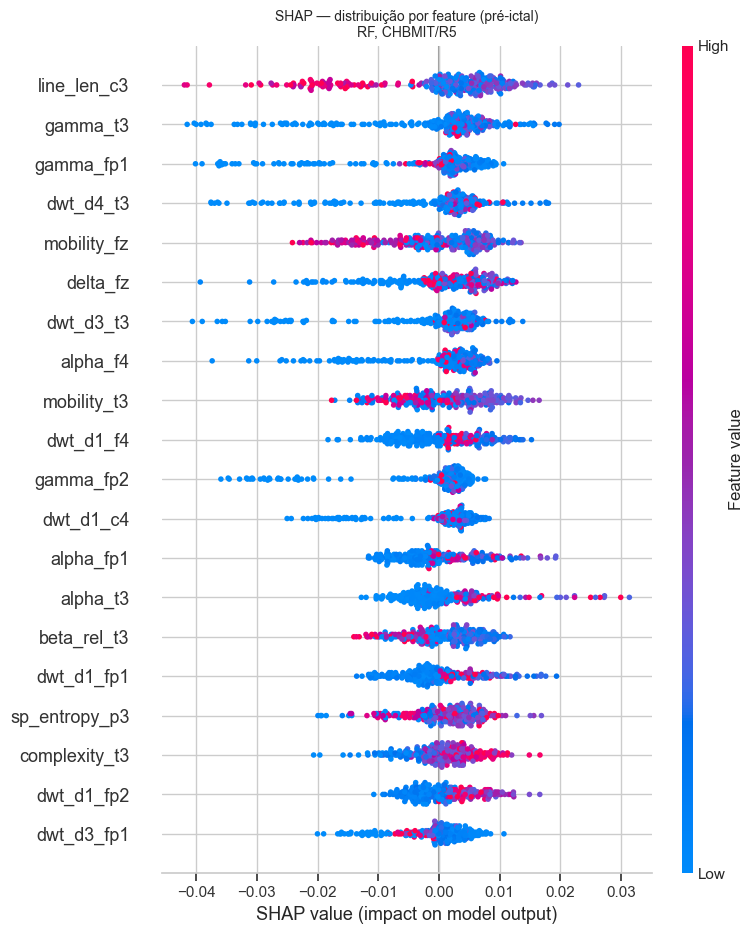

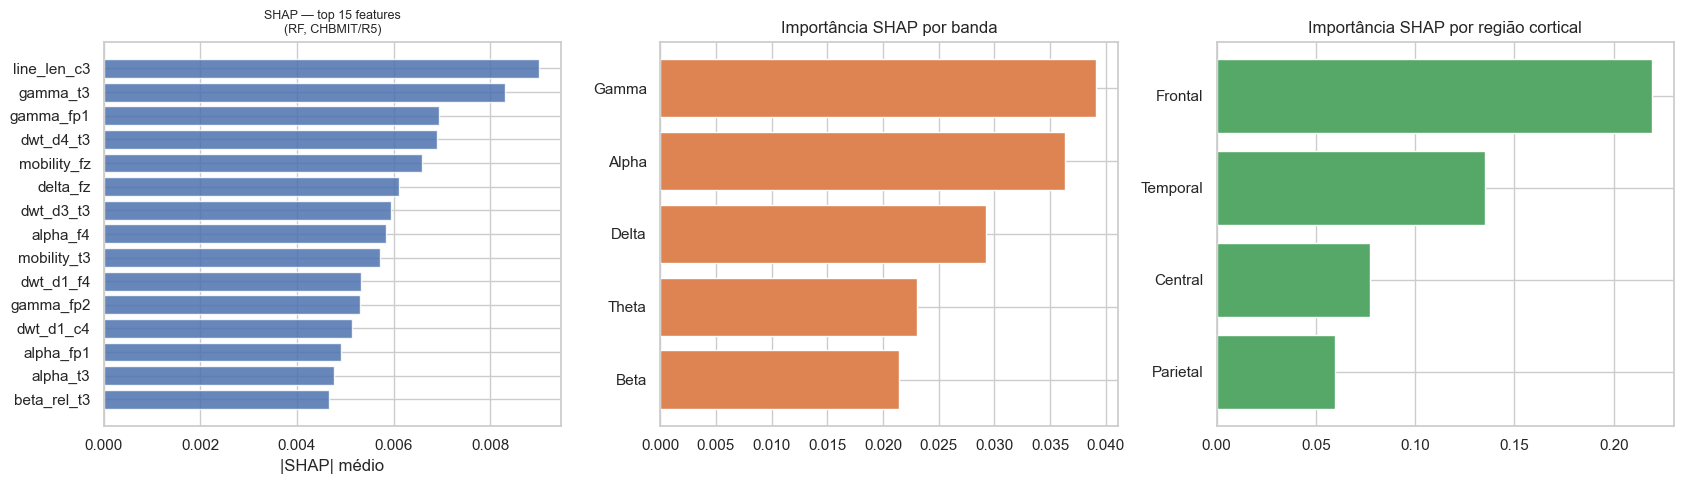

SHAP concluído.
Top 5 features (SHAP): ['line_len_c3', 'gamma_t3', 'gamma_fp1', 'dwt_d4_t3', 'mobility_fz']

Tabela comparativa dos 3 métodos salva em data/results/.

Top 10 features por SHAP:


,feature,model_importance,permutation,shap
0,line_len_c3,0.01098,0.00153,0.00902
1,gamma_t3,0.01058,-0.00015,0.00830
2,gamma_fp1,0.00936,0.00087,0.00693
3,dwt_d4_t3,0.00969,0.00010,0.00690
4,mobility_fz,0.00731,0.00090,0.00659
5,delta_fz,0.00772,0.00022,0.00612
6,dwt_d3_t3,0.00878,0.00030,0.00596
7,alpha_f4,0.00756,0.00077,0.00584
8,mobility_t3,0.00868,0.00038,0.00572
9,dwt_d1_f4,0.00690,0.00048,0.00533


In [11]:
import shap

SHAP_MAX_SAMPLES = 300   # amostras do teste para o SHAP (aumentar se quiser mais precisão)

print(f'Calculando SHAP ({model_venc})...')

# Seleciona amostras estratificadas do teste (50% de cada classe)
rng = np.random.default_rng(42)
idx0 = np.where(y_te == 0)[0]; idx1 = np.where(y_te == 1)[0]
n_each = min(SHAP_MAX_SAMPLES // 2, len(idx0), len(idx1))
idx_sample = np.concatenate([
    rng.choice(idx0, n_each, replace=False),
    rng.choice(idx1, n_each, replace=False)
])
idx_sample = np.sort(idx_sample)
X_shap = X_te_sc[idx_sample]
y_shap = y_te[idx_sample]
print(f'  amostras: {len(X_shap)} ({n_each} interictal + {n_each} pré-ictal)')

# Explainer adequado ao modelo
if model_venc in ('RF', 'XGB'):
    explainer = shap.TreeExplainer(clf_interp)
    shap_values = explainer.shap_values(X_shap)
    # RF retorna lista [classe0, classe1]; XGB retorna array direto
    # shap_values pode ser:
    # - lista [sv_class0, sv_class1] (RF antigo / algumas versões)
    # - array 3D (n, features, classes) (RF novo / shap >= 0.40)
    # - array 2D (n, features) (XGB, LR)
    if isinstance(shap_values, list):
        sv = shap_values[1]
    elif hasattr(shap_values, 'ndim') and shap_values.ndim == 3:
        sv = shap_values[:, :, 1]
    else:
        sv = shap_values
else:
    explainer = shap.LinearExplainer(clf_interp, X_tr_sc)
    shap_values = explainer.shap_values(X_shap)
    sv = shap_values

# ── Beeswarm: distribuição dos valores SHAP por feature (top 20) ──
print('Gerando beeswarm plot...')
shap.initjs()
fig_b = plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_shap, feature_names=feat_names,
                  max_display=20, show=False, plot_type='dot')
plt.title(f'SHAP — distribuição por feature (pré-ictal)\n{model_venc}, {INTERP_DS}/{INTERP_LEVEL}', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f'shap_beeswarm_{INTERP_DS}_{INTERP_LEVEL}.png'),
            dpi=140, bbox_inches='tight')
plt.show()

# ── Bar plot: importância SHAP média por feature ──
shap_mean = np.abs(sv).mean(axis=0)
df_shap = pd.DataFrame({'feature': feat_names, 'shap_mean': shap_mean})
df_shap['base']   = df_shap['feature'].apply(lambda s: s.rsplit('_', 1)[0])
df_shap['chan']   = df_shap['feature'].apply(lambda s: s.rsplit('_', 1)[1])
df_shap['regiao'] = df_shap['chan'].map(CH_REGION).fillna('Outro')
df_shap['banda']  = df_shap['base'].map(BAND_FEATS).fillna('-')
df_shap = df_shap.sort_values('shap_mean', ascending=False).reset_index(drop=True)
df_shap.to_csv(os.path.join(RESULTS_DIR, f'shap_importance_{INTERP_DS}_{INTERP_LEVEL}.csv'), index=False)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
top_shap = df_shap.head(15).iloc[::-1]
axes[0].barh(top_shap['feature'], top_shap['shap_mean'], color='#4C72B0', alpha=0.85)
axes[0].set_title(f'SHAP — top 15 features\n({model_venc}, {INTERP_DS}/{INTERP_LEVEL})', fontsize=9)
axes[0].set_xlabel('|SHAP| médio')

band_shap = df_shap[df_shap['banda'] != '-'].groupby('banda')['shap_mean'].sum().sort_values()
axes[1].barh(band_shap.index, band_shap.values, color='#DD8452')
axes[1].set_title('Importância SHAP por banda')

reg_shap = df_shap.groupby('regiao')['shap_mean'].sum().sort_values()
axes[2].barh(reg_shap.index, reg_shap.values, color='#55A868')
axes[2].set_title('Importância SHAP por região cortical')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f'shap_importance_{INTERP_DS}_{INTERP_LEVEL}.png'),
            dpi=140, bbox_inches='tight')
plt.show()

print('SHAP concluído.')
print(f'Top 5 features (SHAP): {df_shap["feature"].head(5).tolist()}')
print()

# ── Comparação rápida entre os 3 métodos de importância ──
df_comp = pd.DataFrame({
    'feature'         : feat_names,
    'model_importance': (clf_interp.feature_importances_
                         if model_venc in ('RF','XGB')
                         else np.abs(clf_interp.coef_[0])),
    'permutation'     : perm.importances_mean,
    'shap'            : shap_mean,
})
df_comp = df_comp.sort_values('shap', ascending=False).reset_index(drop=True)
df_comp.to_csv(os.path.join(RESULTS_DIR, f'interpretabilidade_comparacao_{INTERP_DS}_{INTERP_LEVEL}.csv'), index=False)
print('Tabela comparativa dos 3 métodos salva em data/results/.')
print(f'\nTop 10 features por SHAP:')
ipd.display(df_comp.head(10)[['feature','model_importance','permutation','shap']].round(5))


## 9. Encerramento

Resultados gravados em `data/results/`:

- `cenario_A_loso.csv` — generalização entre pacientes;
- `cenario_B_cross_1to1.csv` — transferência entre duas bases;
- `cenario_C_cross_Nto1.csv` — combinação de bases e teste em base não vista;
- `patient_specific.csv` (Notebook 3.5) — verificação de integridade;
- `permutation_importance_{DS}_{level}.csv` — importância por permutação no teste;
- `shap_importance_{DS}_{level}.csv` — valores SHAP médios por feature;
- `interpretabilidade_comparacao_{DS}_{level}.csv` — comparação dos 3 métodos;
- `figures/` — comparações, impacto de canais, beeswarm SHAP, importância por região e banda.

A etapa de aprendizado profundo (1D-CNN, CNN-LSTM, TCN) constitui o Notebook 5, em trabalho posterior.
